# Atelier Préparation de Données Textuelles

## Contexte 

Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client. Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles. 

## Partie 1 – Exploration du corpus

### 1) Charger les données CSV ; 

In [1]:
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 2) Combien d'avis contient le dataset ? 

In [2]:
nb_avis = df.shape[0]
print(f"Nombre d'avis : {nb_avis}")

Nombre d'avis : 1200


### 3) Combien de colonnes possède-t-il ?

In [3]:
nb_colonnes = df.shape[1]
print(f"Nombre de colonnes : {nb_colonnes}")

Nombre de colonnes : 8


### 4) Quel est le type de chaque colonne ?

In [4]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ? 

In [5]:
df.isnull().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères. 

In [7]:
import re

# Texte normal (premier avis sans rien de particulier)
print("Texte normal :", df.loc[0, "texte"])

# Texte vide (valeur manquante)
print("Texte vide :", df[df["texte"].isnull()]["texte"].head(1).values)

# Texte contenant une URL
print("Avec URL :", df[df["texte"].str.contains(r"http\S+", na=False)]["texte"].iloc[0])

# Texte contenant une mention (@quelquechose)
print("Avec mention :", df[df["texte"].str.contains(r"@\w+", na=False)]["texte"].iloc[0])

# Texte contenant un hashtag (#quelquechose)
print("Avec hashtag :", df[df["texte"].str.contains(r"#\w+", na=False)]["texte"].iloc[0])

# Texte contenant des emojis
print("Avec emoji :", df[df["texte"].str.contains(r"[\U0001F300-\U0001FAFF]", na=False, regex=True)]["texte"].iloc[0])

# Texte avec beaucoup de ponctuation
print("Beaucoup de ponctuation :", df[df["texte"].str.contains(r"[!?]{2,}", na=False)]["texte"].iloc[0])

# Texte en majuscules
print("En majuscules :", df[df["texte"].str.isupper() == True]["texte"].iloc[0])

# Texte avec répétition de caractères (version sans warning)
pattern_repetition = re.compile(r"(.)\1{2,}")
mask_repetition = df["texte"].apply(lambda t: bool(pattern_repetition.search(t)) if pd.notna(t) else False)
print("Répétition de caractères :", df[mask_repetition]["texte"].iloc[0])

Texte normal : Très  bonne  expérience,  simple  et  efficace.
Texte vide : <StringArray>
[nan]
Length: 1, dtype: str
Avec URL : Produit parfait, rien à signaler. https://example.com/commande/17
Avec mention : @client Livraison rapide et produit conforme à mes attentes.
Avec hashtag : Très satisfait de mon achat 👍 #avis
Avec emoji : Très satisfait de mon achat 👍 #avis
Beaucoup de ponctuation : Produit excellent, je suis très satisfait. !!!
En majuscules : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Répétition de caractères : Produit excellent, je suis très satisfait. !!!


### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

In [8]:
df["longueur"] = df["texte"].apply(lambda t: len(t.split()) if pd.notna(t) else 0)

longueur_min = df["longueur"].min()
longueur_max = df["longueur"].max()
longueur_moyenne = df["longueur"].mean()
longueur_mediane = df["longueur"].median()
quartiles = df["longueur"].quantile([0.25, 0.5, 0.75])

print(f"Longueur minimale : {longueur_min}")
print(f"Longueur maximale : {longueur_max}")
print(f"Longueur moyenne : {longueur_moyenne:.2f}")
print(f"Longueur médiane : {longueur_mediane}")
print("Quartiles :\n", quartiles)

Longueur minimale : 0
Longueur maximale : 120
Longueur moyenne : 6.96
Longueur médiane : 7.0
Quartiles :
 0.25    6.0
0.50    7.0
0.75    8.0
Name: longueur, dtype: float64


### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

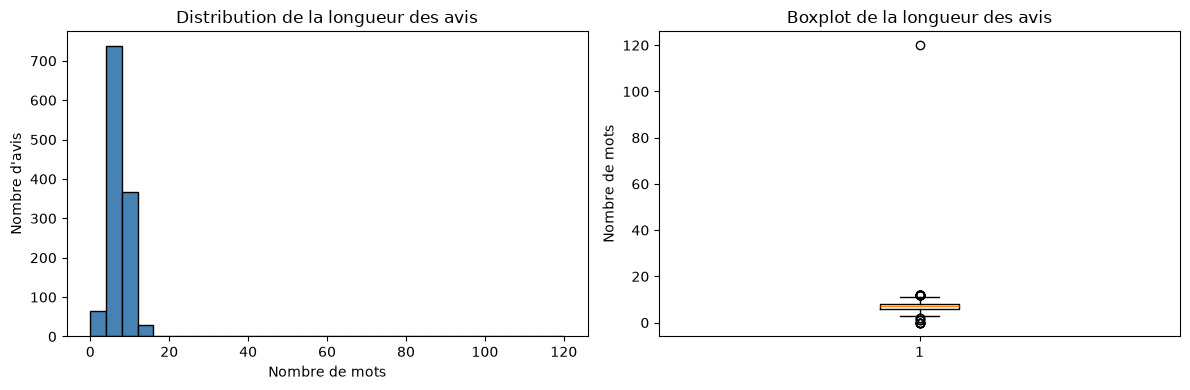

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(df["longueur"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution de la longueur des avis")
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Nombre d'avis")

# Boxplot
axes[1].boxplot(df["longueur"], orientation="vertical")
axes[1].set_title("Boxplot de la longueur des avis")
axes[1].set_ylabel("Nombre de mots")

plt.tight_layout()
plt.show()

### Analyse de la distribution de la longueur des avis

**a) Existe-t-il des textes anormalement longs ?**

Oui. Le boxplot fait apparaître des points isolés (outliers) nettement au-dessus de la 
moustache supérieure, correspondant à des avis atteignant jusqu'à 120 mots, alors que la 
médiane n'est que de 7 mots. Ces avis très longs sortent clairement du comportement habituel 
du corpus.

**b) Existe-t-il beaucoup de textes très courts ?**

Oui, très majoritairement. L'histogramme montre une barre très haute (plus de 700 avis) 
concentrée dans la tranche 0-20 mots, ce qui confirme que la quasi-totalité des avis du 
dataset sont courts. Le reste des valeurs s'étale ensuite en une longue traîne peu peuplée 
jusqu'à 120 mots.